In [1]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.manifold import TSNE

import zglitchfunc as gf

In [2]:
clust = 'gspy'
run = 'O3a'

arq_name = f'{clust}{run}'

In [3]:
# base_data = '/home/esanches/Projetos/tSNE/Virgo/'
repository = f'C:/Users/erick/Downloads/JupyterNotebook/github/tSNE_analysis/zrepository/{clust}/{run}/'

# filterr = True
# dt = 2

## tSNE plots for O3a

### Perplexity and dt configurations

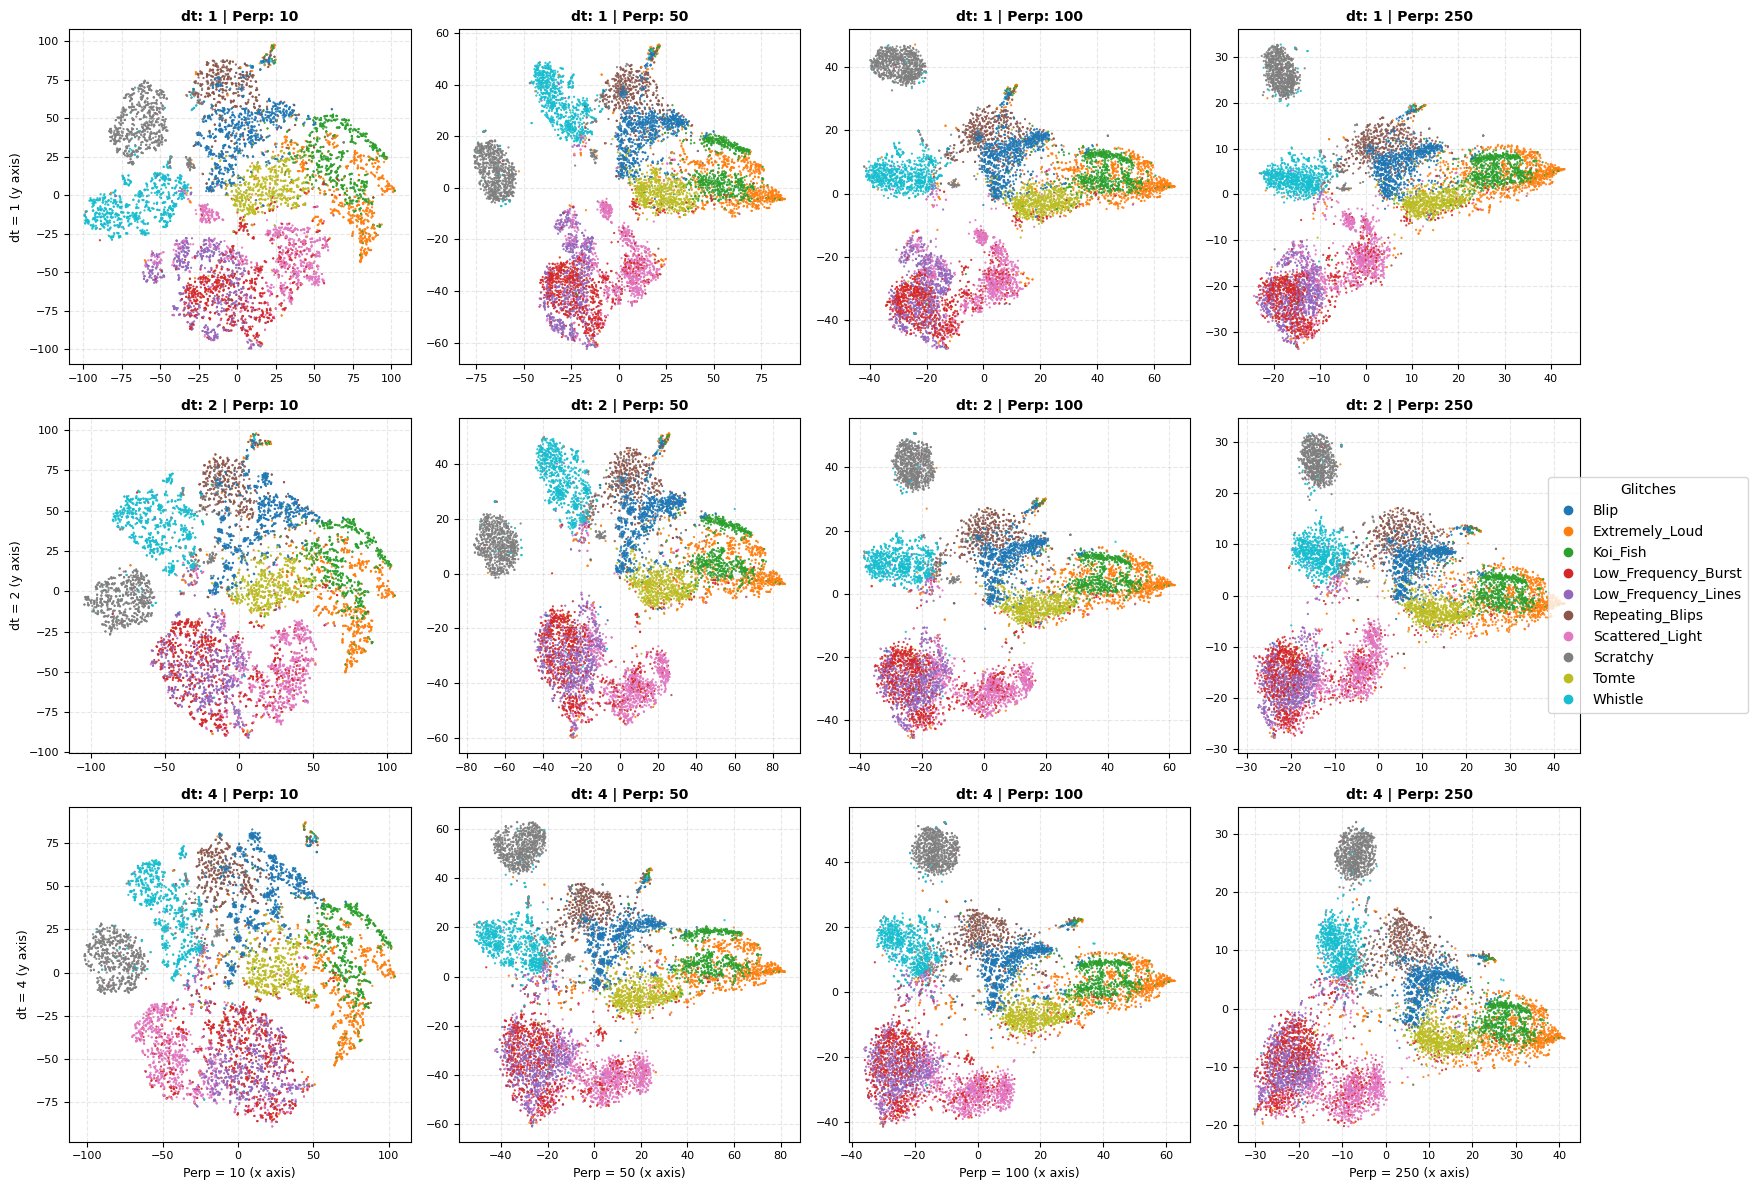

In [22]:
lista_dt = [1, 2, 4]
lista_perp = [10, 50, 100, 250]

fig, axs = plt.subplots(len(lista_dt), len(lista_perp), figsize=(4*len(lista_perp), 4*len(lista_dt)))
# fig, axs = plt.subplots(len(lista_dt), len(lista_perp), figsize=(12, 9), sharex=False, sharey=False)

le = LabelEncoder()

for i, dt in enumerate(lista_dt):
    
    final_vecs = np.load(f"{repository}vecs_{arq_name}_dt{str(dt)}.npy")
    final_labs = np.load(f"{repository}labs_{arq_name}_dt{str(dt)}.npy")
    labels = le.fit_transform(final_labs.ravel())

    for j, perp in enumerate(lista_perp):
        
        tsne = TSNE(n_components=2, n_jobs=-1, verbose=0, perplexity=perp, 
                    learning_rate=200, max_iter=1000, metric="euclidean", random_state=0)
        proj = tsne.fit_transform(final_vecs)
        
        ax = axs[i, j]
        sc = ax.scatter(proj[:, 0], proj[:, 1], s=0.3, c=labels, cmap="tab10")
        ax.set_title(f"dt: {dt} | Perp: {perp}", fontsize=10, fontweight='bold')
        ax.tick_params(axis='both', which='major', labelsize=8)
        ax.grid(True, linestyle="--", alpha=0.3)
        
        if j == 0:
            ax.set_ylabel(f"dt = {dt} (y axis)", fontsize=9)
        if i == len(lista_dt) - 1:
            ax.set_xlabel(f"Perp = {perp} (x axis)", fontsize=9)

plt.tight_layout()
# plt.subplots_adjust(wspace=0.02, hspace=0.02, left=0.06, right=0.82, top=0.96, bottom=0.06)
fig.legend(handles=sc.legend_elements()[0], labels=list(le.classes_), title="Glitches", loc='center right', bbox_to_anchor=(1.1, 0.5))
plt.show()

One of the best configurations is when dt=2 and perplexity=100.

In [4]:
dt, perp = 2, 100

In [25]:
final_vecs = np.load(f"{repository}vecs_{arq_name}_dt{str(dt)}.npy")
final_labs = np.load(f"{repository}labs_{arq_name}_dt{str(dt)}.npy")

le = LabelEncoder()
labels = le.fit_transform(final_labs.ravel())

tsne = TSNE(n_components=2, n_jobs=-1, verbose=0, perplexity=perp, 
            learning_rate=200, max_iter=1000, metric="euclidean", random_state=0)
proj = tsne.fit_transform(final_vecs)

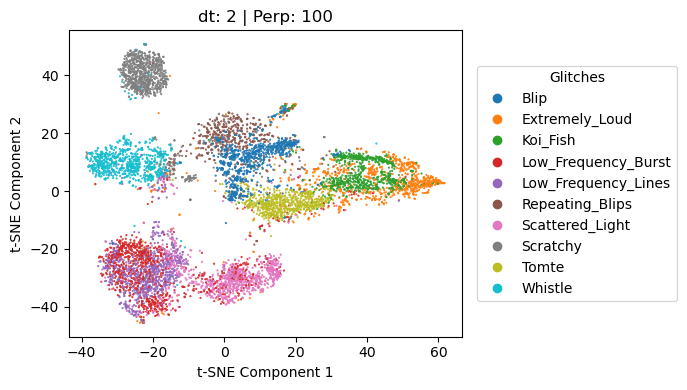

In [26]:
plt.figure(figsize=(7, 4))

sc = plt.scatter(proj[:, 0], proj[:, 1], s=0.3, c=labels, cmap="tab10")

plt.title(f"dt: {dt} | Perp: {perp}", fontsize=12)
plt.xlabel("t-SNE Component 1", fontsize=10)
plt.ylabel("t-SNE Component 2", fontsize=10)

plt.legend(handles=sc.legend_elements()[0], labels=list(le.classes_), 
          title="Glitches", loc='center left', bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()
plt.show()

### Seasonality

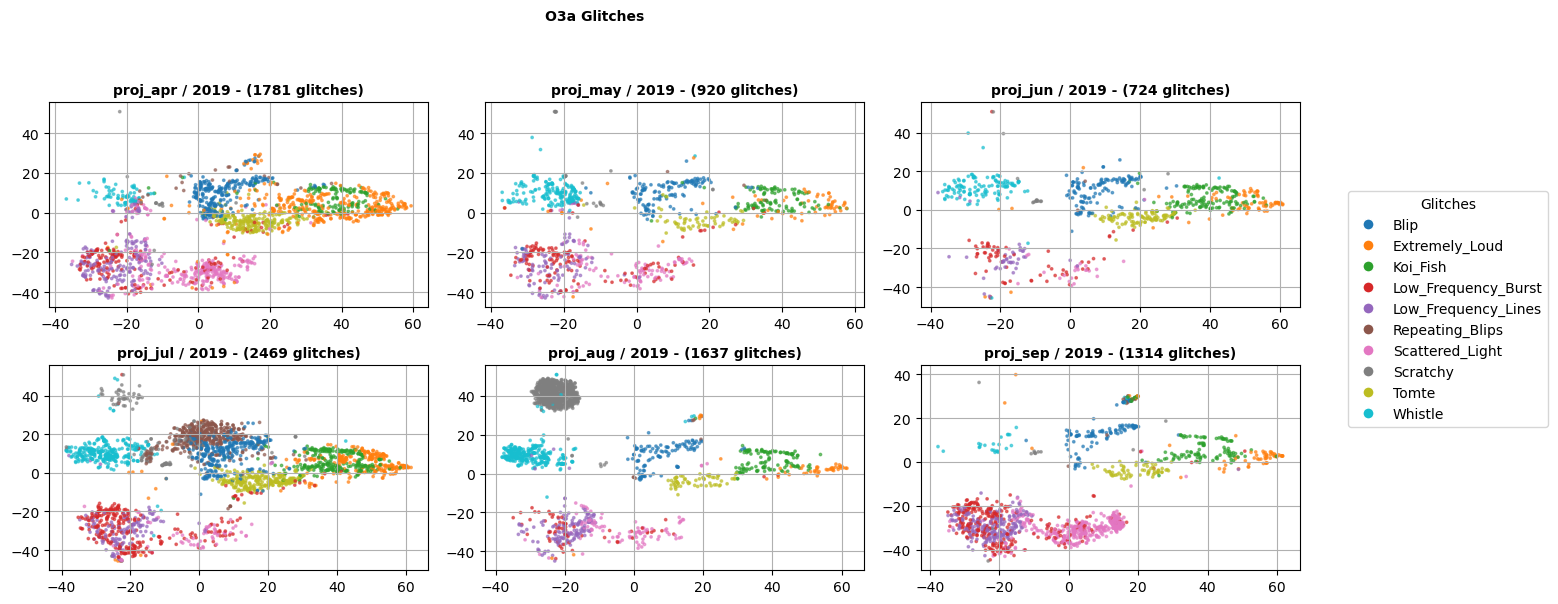

In [5]:
o3a_intervals = {
    'Apr': (1238166018, 1240761618),
    'May': (1240761618, 1243440018),
    'Jun': (1243440018, 1246032018),
    'Jul': (1243440018, 1248710418),
    'Aug': (1248710418, 1251388818),
    'Sep': (1251388818, 1253980818)
}
projs = gf.projections(repository, arq_name, dt, perp, o3a_intervals)
gf.plot_saz(projs, 'O3a Glitches')

We observe that, on average, **Repeating_Blips appears in July** and **Scratchy appears in August**.

**Scattered_Light ~ september**

The **O3b** seismometers OK channels are

From Central Experimental building:
* V1-ENV_CEB_SEIS_W - V1-ENV_CEB_SEIS_V - V1-ENV_CEB_SEIS_N

From North End Building:
* V1-ENV_NEB_SEIS_V - V1-ENV_NEB_SEIS_W - V1-ENV_NEB_SEIS_N

From External Detection Bench:
* V1-ENV_EDB_SEIS_Y - V1-ENV_EDB_SEIS_Z - V1-ENV_EDB_SEIS_X

From Squeezing bench (Optical bench responsible for producing and injecting squeezed vacuum states into the interferometer to reduce the detector's quantum noise):
* V1-ENV_SQZ_SEIS_Y - V1-ENV_SQZ_SEIS_X - V1-ENV_SQZ_SEIS_Z

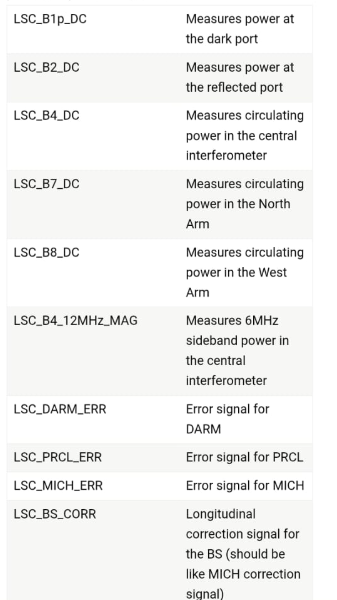

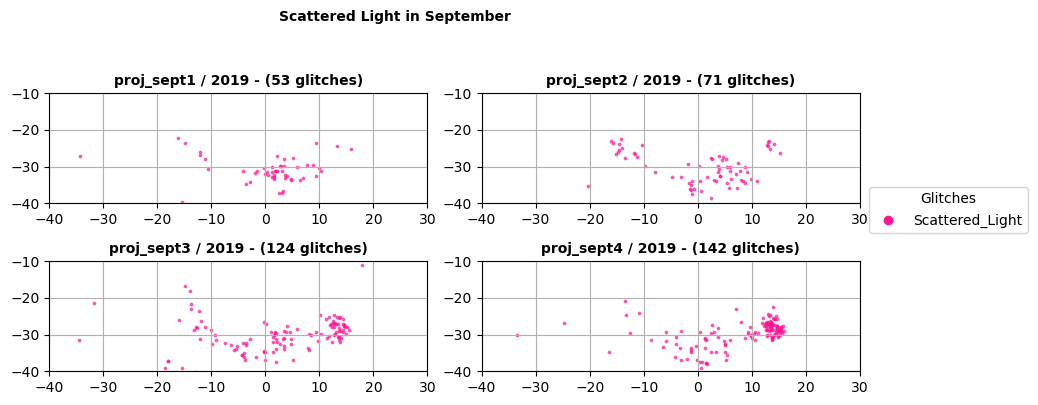

In [6]:
o3a_september_intervals = {
    'sept1': (1251331218, 1252000818),  #01/sep to 08/sep
    'sept2': (1252000818, 1252670418),  #08/sep to 15/sep
    'sept3': (1252670418, 1253340018),  #15/sep to 22/sep
    'sept4': (1253340018, 1254009618),  #22/sep to 29/sep
}
projs = gf.projections(repository, arq_name, dt, perp, o3a_september_intervals)
final_projs = {key: df[df['label'] == 'Scattered_Light'] for key, df in projs.items()}

gf.plot_saz(final_projs, 'Scattered Light in September', 'deeppink', xlim=(-40,30), ylim=(-40, -10))

Repeating_blips ~ July

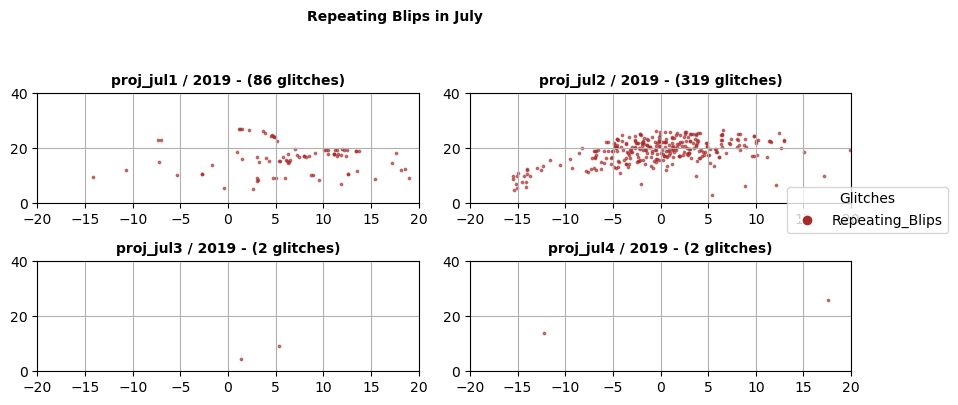

In [33]:
o3a_july_intervals = {
    'jul1': (1245974418, 1246644018),
    'jul2': (1246644018, 1247313618),
    'jul3': (1247313618, 1247983218),
    'jul4': (1247983218, 1248652818),
}
projs = gf.projections(repository, arq_name, dt, perp, o3a_july_intervals)
final_projs = {key: df[df['label'] == 'Repeating_Blips'] for key, df in projs.items()}

gf.plot_saz(final_projs, 'Repeating Blips in July', 'brown', xlim=(-20,20), ylim=(0, 40))

Repeating_blips ~ July second week

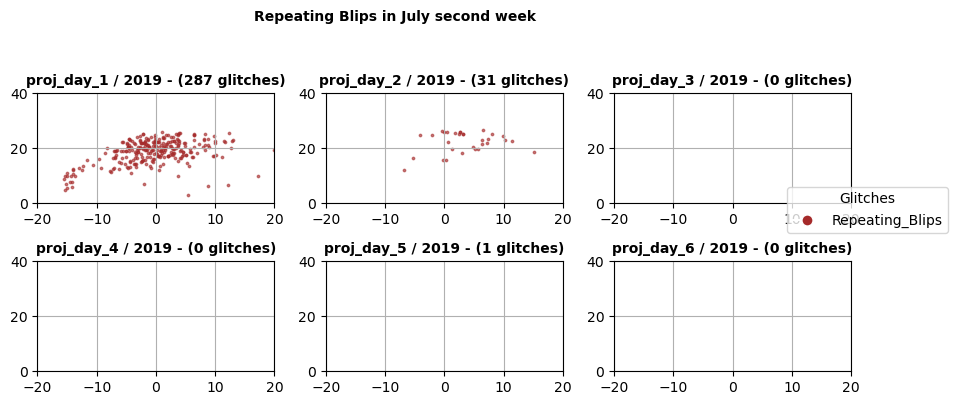

In [34]:
o3a_july_intervals = {
    'day_1': (1246644018, 1246739675),
    'day_2': (1246739675, 1246835332),
    'day_3': (1246835332, 1246930989),
    'day_4': (1246930989, 1247026646),
    'day_5': (1247026646, 1247122303),
    'day_6': (1247122303, 1247217960),
}
projs = gf.projections(repository, arq_name, dt, perp, o3a_july_intervals)
final_projs = {key: df[df['label'] == 'Repeating_Blips'] for key, df in projs.items()}

gf.plot_saz(final_projs, 'Repeating Blips in July second week', 'brown', xlim=(-20, 20), ylim=(0, 40))

Scratchy ~ August

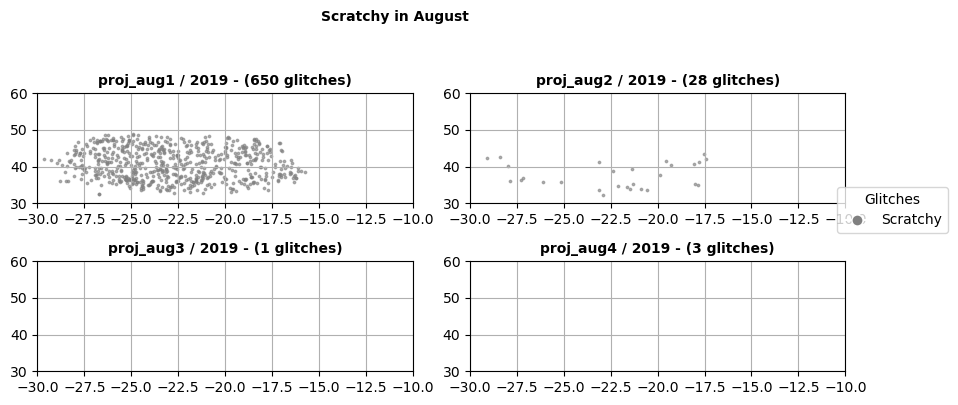

In [35]:
o3a_aug_intervals = {
    'aug1': (1248652818, 1249322418),
    'aug2': (1249322418, 1249992018),
    'aug3': (1249992018, 1250661618),
    'aug4': (1250661618, 1251331218),
}
projs = gf.projections(repository, arq_name, dt, perp, o3a_aug_intervals)
final_projs = {key: df[df['label'] == 'Scratchy'] for key, df in projs.items()}

gf.plot_saz(final_projs, 'Scratchy in August', 'gray', xlim=(-30,-10), ylim=(30,60))

Scratchy ~ August first week

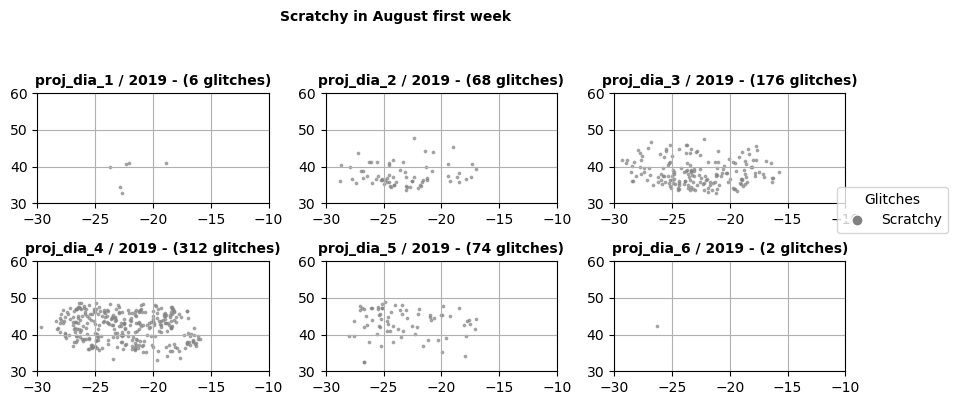

In [36]:
o3a_aug_intervals = {
    'dia_1': (1248652818, 1248748475),
    'dia_2': (1248748475, 1248844132),
    'dia_3': (1248844132, 1248939789),
    'dia_4': (1248939789, 1249035446),
    'dia_5': (1249035446, 1249131103),
    'dia_6': (1249131103, 1249226760),
}
projs = gf.projections(repository, arq_name, dt, perp, o3a_aug_intervals)
final_projs = {key: df[df['label'] == 'Scratchy'] for key, df in projs.items()}

gf.plot_saz(final_projs, 'Scratchy in August first week', 'gray', xlim=(-30,-10), ylim=(30,60))